In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_excel('Health Insurance Fraud Claims.xlsx')
df.head()

,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod,Cluster,ClaimLegitimacy
0,4d76c7f7-d36a-4139-b451-a9a4ad10d7d5,19cf2638-3ec0-4ed9-9995-d9ba4553813a,a3d0cc80-dffe-40ff-a302-23c8ffeedb36,7820.52,2024-07-08,Ta150,iO013,96,F,Orthopedics,Pending,57595.11,Single,Employed,New Alishaview,Inpatient,Paper,3,Legitimate
1,e35193b4-3609-492b-866a-98de19317e9c,5c4bb6c5-4dd3-4a86-85fa-f36c0d8debff,a9f25acf-92b8-45e2-9cef-87bd07d0a591,5453.86,2024-07-08,Fo766,jR349,95,M,Cardiology,Denied,140772.72,Widowed,Employed,East Curtis,Inpatient,Online,2,Legitimate
2,1f3fa373-25ed-4ff4-b6c7-38dcb2fb297f,777866e0-4d10-45a8-a7b4-dbdaa26d5a81,951b1e08-9948-4956-80e5-9277f16bd290,8229.86,2024-07-08,AX876,uU479,10,M,Cardiology,Pending,69803.19,Married,Student,Lake Jennifer,Emergency,Online,3,Legitimate
3,af6a68f4-8319-47b1-a28b-77de01572851,9d7c53ee-eb1a-4f07-9e3a-e86cf82e9f0f,de9e193a-f9a1-4d63-9345-aefe75694628,9519.16,2024-07-08,SQ441,Xs264,59,F,Cardiology,Pending,135530.12,Married,Employed,Martinstad,Routine,Phone,2,Legitimate
4,417fe944-79d2-4610-81c4-a2d496f29ee4,db14b0ca-ac2a-4e83-b085-947ea32e7587,5c7d7045-71b6-4c15-937c-43e4cfe65bf4,3226.15,2024-07-08,FK970,PV476,36,F,Neurology,Approved,36995.52,Divorced,Unemployed,Thomasfurt,Inpatient,Phone,1,Legitimate


In [3]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Health Insurance Fraud Claims Profiling Report", explorative=True)
profile.to_file("health_insurance_fraud_claims_profiling_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 58.91it/s]


In [4]:
drop_columns = ['ClaimID', 'PatientID', 'ProviderID', 'ClaimDate', 'DiagnosisCode', 'ProcedureCode', 'ProviderLocation']
df.drop(columns=drop_columns, inplace=True)

In [5]:
df.head()

,ClaimAmount,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ClaimType,ClaimSubmissionMethod,Cluster,ClaimLegitimacy
0,7820.52,96,F,Orthopedics,Pending,57595.11,Single,Employed,Inpatient,Paper,3,Legitimate
1,5453.86,95,M,Cardiology,Denied,140772.72,Widowed,Employed,Inpatient,Online,2,Legitimate
2,8229.86,10,M,Cardiology,Pending,69803.19,Married,Student,Emergency,Online,3,Legitimate
3,9519.16,59,F,Cardiology,Pending,135530.12,Married,Employed,Routine,Phone,2,Legitimate
4,3226.15,36,F,Neurology,Approved,36995.52,Divorced,Unemployed,Inpatient,Phone,1,Legitimate


In [6]:
# Identifying feature types
num_col = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = df.select_dtypes(include=['object']).drop(columns=['ClaimLegitimacy']).columns.to_list()
target_col = 'ClaimLegitimacy'

In [7]:
# Splitting the data
X = df.drop(target_col, axis=1)
y = df[target_col]

In [8]:
# Splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
# Numeric Pipeline
num_pipeline = Pipeline(steps=[
    ( 'imputer', SimpleImputer(strategy='mean') ),
    ( 'scaler', StandardScaler() )
])

# Categorical Pipeline
cat_pipeline = Pipeline(steps=[
    ( 'imputer', SimpleImputer(strategy='most_frequent') ),
    ( 'onehot', OneHotEncoder(handle_unknown='ignore') )
])

In [10]:
# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ( 'num', num_pipeline, num_col ),
    ( 'cat', cat_pipeline, cat_col )
])

In [11]:
# Base Learners
clf_logreg = LogisticRegression(random_state=42)
clf_svc = SVC(probability=True, random_state=42)
clf_rf = RandomForestClassifier(random_state=42)
clf_gb = GradientBoostingClassifier(random_state=42)

In [12]:
# Models Dictionary
models = {
    'Logistic Regression': clf_logreg,
    'Support Vector Machine': clf_svc,
    'Random Forest': clf_rf,
    'Gradient Boosting': clf_gb,
}

model_report = []

In [14]:
# Cross Validation and Model Evaluation (Using GridSearchCV for Hyperparameter Tuning)
param_grid = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
    },
    'Support Vector Machine': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2]
    },
}

model_grid = {}
for model_name, model in models.items():
    # Create Pipeline
    pipeline = Pipeline(steps=[
        ( 'preprocessor', preprocessor ),
        ( 'classifier', model )
    ])
    
    # Hyperparameter Tuning
    grid_search = GridSearchCV(pipeline, param_grid[model_name], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    model_grid[model_name] = best_model.named_steps['classifier']
    
    # Predictions
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=None)[0]
    recall = recall_score(y_test, y_pred, average=None)[0]
    f1 = f1_score(y_test, y_pred, average=None)[0]
    roc_auc = roc_auc_score(y_test, y_proba)  
    
    
    model_report.append({
        'Model': model_name,
        'CV' : 'GridSearchCV',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,    
        'ROC-AUC': roc_auc
    })
    

In [17]:
# Cross Validation and Model Evaluation (Using RandomizedSearchCV for Hyperparameter Tuning)
param_random = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
    },
    'Support Vector Machine': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    },
    'Random Forest': {
        'classifier__n_estimators': randint(100, 500),
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': randint(2, 10)
    },
    'Gradient Boosting': {
        'classifier__n_estimators': randint(100, 500),
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__min_samples_split': randint(2, 10)
    },
}

model_random = {}
for model_name, model in models.items():
    # Create Pipeline
    pipeline = Pipeline(steps=[
        ( 'preprocessor', preprocessor ),
        ( 'classifier', model )
    ])
    
    # Hyperparameter Tuning
    randomized_search = RandomizedSearchCV(pipeline, param_random[model_name], cv=5, scoring='accuracy', n_jobs=-1)
    randomized_search.fit(X_train, y_train)
    best_model = randomized_search.best_estimator_
    
    model_random[model_name] = best_model.named_steps['classifier']
    
    # Predictions
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=None)[0]
    recall = recall_score(y_test, y_pred, average=None)[0]
    f1 = f1_score(y_test, y_pred, average=None)[0]
    roc_auc = roc_auc_score(y_test, y_proba)  
    
    
    model_report.append({
        'Model': model_name,
        'CV' : 'RandomizedSearchCV',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,    
        'ROC-AUC': roc_auc
    })
    

In [18]:
# Ensemble Models
voting_clf = VotingClassifier(estimators=[
    ( 'logreg', model_grid['Logistic Regression']),
    ( 'svc', model_grid['Support Vector Machine']),
    ( 'rf', model_grid['Random Forest']),
    ( 'gb', model_grid['Gradient Boosting'] )
], voting='soft')

stacking_clf = StackingClassifier(estimators=[
    ( 'svc', model_grid['Support Vector Machine']),
    ( 'rf', model_grid['Random Forest']),
    ( 'gb', model_grid['Gradient Boosting'])
], final_estimator=model_grid['Logistic Regression'], passthrough=True)


ensemble_models_grid = {
    'Voting Classifier': voting_clf,
    'Stacking Classifier': stacking_clf
}

In [19]:
for model_name, model in ensemble_models_grid.items():
    # Create Pipeline
    pipeline = Pipeline(steps=[
        ( 'preprocessor', preprocessor ),
        ( 'classifier', model )
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=None)[0]
    recall = recall_score(y_test, y_pred, average=None)[0]
    f1 = f1_score(y_test, y_pred, average=None)[0]
    roc_auc = roc_auc_score(y_test, y_proba)  

    model_report.append({
        'Model': model_name,
        'CV' : 'GridSearchCV',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,    
        'ROC-AUC': roc_auc
    })
        

In [20]:
voting_clf = VotingClassifier(estimators=[
    ( 'logreg', model_random['Logistic Regression']),
    ( 'svc', model_random['Support Vector Machine']),
    ( 'rf', model_random['Random Forest']),
    ( 'gb', model_random['Gradient Boosting'] )
], voting='soft')

stacking_clf = StackingClassifier(estimators=[
    ( 'svc', model_random['Support Vector Machine']),
    ( 'rf', model_random['Random Forest']),
    ( 'gb', model_random['Gradient Boosting'])
], final_estimator=model_random['Logistic Regression'], passthrough=True)


ensemble_models_random = {
    'Voting Classifier': voting_clf,
    'Stacking Classifier': stacking_clf
}

In [21]:
for model_name, model in ensemble_models_random.items():
    # Create Pipeline
    pipeline = Pipeline(steps=[
        ( 'preprocessor', preprocessor ),
        ( 'classifier', model )
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=None)[0]
    recall = recall_score(y_test, y_pred, average=None)[0]
    f1 = f1_score(y_test, y_pred, average=None)[0]
    roc_auc = roc_auc_score(y_test, y_proba)  

    model_report.append({
        'Model': model_name,
        'CV' : 'RandomizedSearchCV',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,    
        'ROC-AUC': roc_auc
    })
        

In [22]:
model_report = pd.DataFrame(model_report)
model_report.sort_values(by='ROC-AUC', ascending=False, inplace=True)   
model_report.reset_index(drop=True, inplace=True) 

In [23]:
model_report

,Model,CV,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,GridSearchCV,0.998889,1.000000,0.981481,0.990654,0.999956
1,Random Forest,RandomizedSearchCV,0.998889,1.000000,0.981481,0.990654,0.999956
2,Stacking Classifier,RandomizedSearchCV,0.997778,0.981481,0.981481,0.981481,0.999934
3,Voting Classifier,GridSearchCV,0.996667,0.963636,0.981481,0.972477,0.999891
4,Voting Classifier,RandomizedSearchCV,0.996667,0.963636,0.981481,0.972477,0.999891
5,Stacking Classifier,GridSearchCV,0.996667,0.963636,0.981481,0.972477,0.999891
6,Gradient Boosting,GridSearchCV,0.998889,0.981818,1.000000,0.990826,0.999398
7,Gradient Boosting,RandomizedSearchCV,0.998889,0.981818,1.000000,0.990826,0.999398
8,Support Vector Machine,RandomizedSearchCV,0.992222,0.927273,0.944444,0.935780,0.996520
9,Support Vector Machine,GridSearchCV,0.992222,0.927273,0.944444,0.935780,0.996520


In [24]:
# Final Model Training and Evaluation
best_model_name = model_report.loc[0]['Model']
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

final_pipeline.fit(X_train, y_train)

y_final_pred = final_pipeline.predict(X_test)
y_final_proba = final_pipeline.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_final_pred)
final_precision = precision_score(y_test, y_final_pred, average=None)[0]
final_recall = recall_score(y_test, y_final_pred, average=None)[0]
final_f1 = f1_score(y_test, y_final_pred, average=None)[0]
final_roc_auc = roc_auc_score(y_test, y_final_proba)

print(f"Final Model: {best_model_name}")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall: {final_recall:.4f}")
print(f"F1-Score: {final_f1:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")

Final Model: Random Forest
Accuracy: 0.9989
Precision: 1.0000
Recall: 0.9815
F1-Score: 0.9907
ROC-AUC: 0.9998


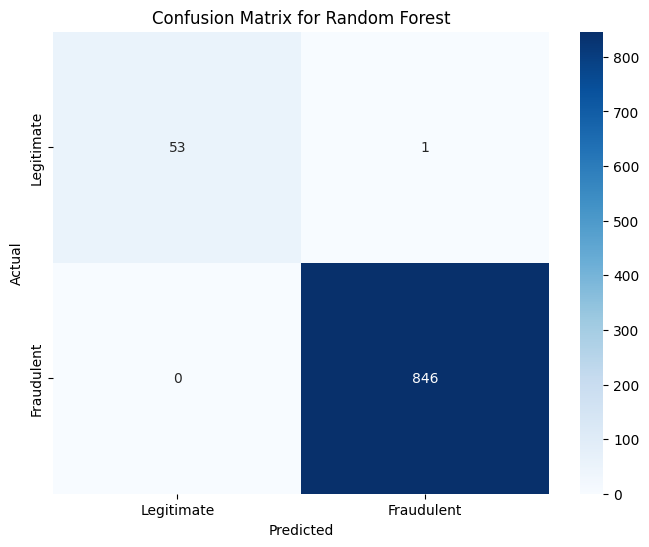

In [25]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_final_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()


In [27]:
import pickle
with open('health_insurance_fraud_claims_prediction_model.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)